# TADs Connection with Age

Analysis of the relationship between TAD border changes in schizophrenia and age-related changes in healthy controls.

In [ ]:
import pandas as pd
import numpy as np
from itertools import chain
from tqdm import tqdm
import os
from os import listdir
import glob
import json
import seaborn as sns
import cooler
import bioframe
import cooltools
from matplotlib_venn import venn2
from cooltools.lib.numutils import fill_diag
from statsmodels.stats.multitest import multipletests, fdrcorrection
from os.path import isfile, join
import warnings
import logging
import math
import matplotlib.pyplot as plt
import scipy
import scipy.stats as stats
from statannot import add_stat_annotation
from scipy.stats import ttest_ind, mannwhitneyu, fisher_exact
import pyranges as pr
from pybedtools import BedTool as pbt
import upsetplot
import gseapy as gp
from gseapy import barplot, dotplot
import rpy2
from collections import defaultdict
import concurrent.futures
from matplotlib.colors import PowerNorm
from dotenv import load_dotenv

warnings.simplefilter(action='ignore', category=FutureWarning)

%load_ext rpy2.ipython

load_dotenv()
assert os.environ['CONDA_DEFAULT_ENV'] == "hic"

In [150]:
merged_all_clusters =pd.read_pickle("./tads_additional_files/merged_bed_with_tads_clustering_neurons.pickle")
merged_all_clusters['num'] = [i for i in range(merged_all_clusters.shape[0])]
merged_all_clusters['group'] = merged_all_clusters.source.apply(lambda x: "SZ" if "SZ" in x else "Healthy")

In [152]:
samples_with_age = {
'HC-2Mplus': 62,
'HC-3Mplus': 36,
'HC-91plus': 59,
'HC24plus': 54,
'HC-318plus': 58,
'HCM12plus': 35,
'SZ-01plus': 36,
'SZ-03plus': 57,
'SZ08plus': 56,
'SZ10plus': 50,
'SZ20plus': 37,
'SZ6plus': 62
}
age_group = {}
for label, age in samples_with_age.items():
    if age <= 40:
        age_group[label] = "Young"
    elif 40 < age <= 57:
        age_group[label] = "Adult"
    else:
        age_group[label] = "Adult"

merged_all_clusters['sample_name'] = merged_all_clusters.source.apply(lambda x: x.split("_")[0])
merged_all_clusters['age_group'] = merged_all_clusters['sample_name'].map(age_group)
df = merged_all_clusters[[ 'num','cluster', 'boundary_strength_150000', 'group', 'age_group']]

Check Intersection

Get Fisher Test

In [ ]:
N_QUANTILES = 10  
def get_cluster_group_stats(df, group_col, stat_col, group1, group2):
    out = (
        df[df[group_col].isin([group1, group2])]
        .groupby(['cluster', group_col])[stat_col]
        .median()
        .unstack()
        .rename(columns={group1: f"{group_col}_{group1}", group2: f"{group_col}_{group2}"})
    )
    return out

column = "boundary_strength_150000"

sz_hc = get_cluster_group_stats(df, 'group', column, 'SZ', 'Healthy')
sz_hc['sz_hc_log2fc'] = np.log2(sz_hc['group_SZ'] / sz_hc['group_Healthy'])

healthy = df[df['group'] == 'Healthy']
hc_age = (
    healthy.groupby(['cluster', 'age_group'])[column]
    .median()
    .unstack()
    .rename(columns={'Young':'HC_Young', 'Adult':'HC_Adult'})
)
hc_age['hc_old_young_log2fc'] = np.log2(hc_age['HC_Adult'] / hc_age['HC_Young'])
merged = pd.merge(sz_hc, hc_age, left_index=True, right_index=True, how='inner').dropna(subset=['sz_hc_log2fc','hc_old_young_log2fc'])
merged['sz_hc_quantile'] = pd.qcut(merged['sz_hc_log2fc'], N_QUANTILES, labels=False, duplicates='drop')
merged['hc_old_young_quantile'] = pd.qcut(merged['hc_old_young_log2fc'], N_QUANTILES, labels=False, duplicates='drop')

top_sz_hc = merged[merged['sz_hc_quantile'] == merged['sz_hc_quantile'].max()].index
top_hc_age = merged[merged['hc_old_young_quantile'] == merged['hc_old_young_quantile'].max()].index

overlap_clusters = set(top_sz_hc) & set(top_hc_age)
print(f'Number of top_sz_hc: {len(top_sz_hc)}')
print(f'Number of top_hc_age: {len(top_hc_age)}')
print(f'Number of overlapping clusters in top quantile: {len(overlap_clusters)}')

# Fisher's exact test for enrichment
table = [
    [len(set(top_sz_hc) & set(top_hc_age)), len(set(top_sz_hc) - set(top_hc_age))],
    [len(set(top_hc_age) - set(top_sz_hc)), len(merged) - len(set(top_sz_hc) | set(top_hc_age))]
]
oddsratio, pval = fisher_exact(table, alternative='greater')
print(f"Fisher's exact test p-value for enrichment: {pval:.3g}, odds ratio: {oddsratio:.3g}")

In [154]:
corr, p_value = scipy.stats.pearsonr(merged['sz_hc_log2fc'], merged['hc_old_young_log2fc'])
print(f"Pearson correlation: {corr:.2f}, p-value: {p_value:.2g}")

Pearson correlation: -0.10, p-value: 1.2e-15


In [155]:
merged['cell_label'] = merged['sz_hc_quantile'].astype(str) + '_' + merged['hc_old_young_quantile'].astype(str)
merged_all_clusters = merged_all_clusters.merge(merged['cell_label'], left_on='cluster', right_index=True, how='left')

Check Intersection All Quantiles

In [ ]:
TOTAL_NUM = len(merged.index)
similarity_matrix = np.zeros((N_QUANTILES, N_QUANTILES))
intersection_percentage_matrix = np.zeros((N_QUANTILES, N_QUANTILES))
plt.rcParams["svg.fonttype"] = "none"

for i in range(N_QUANTILES):
    sz_clusters = set(merged[merged['sz_hc_quantile'] == i].index)
    sz_size = len(sz_clusters)
    for j in range(N_QUANTILES):
        hc_clusters = set(merged[merged['hc_old_young_quantile'] == j].index)

        intersection = len(sz_clusters & hc_clusters)
        union = len(sz_clusters | hc_clusters)

        similarity = (intersection / union) if union > 0 else 0
        similarity_matrix[i, j] = similarity

        if sz_size > 0:
            intersection_percentage_matrix[i, j] = intersection / TOTAL_NUM
        else:
            intersection_percentage_matrix[i, j] = 0

# Jaccard similarity with PowerNorm
plt.figure(figsize=(8,7))
ax = sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    norm=PowerNorm(gamma=0.5),
    xticklabels=[f'Q{i+1}' for i in range(N_QUANTILES)],
    yticklabels=[f'Q{i+1}' for i in range(N_QUANTILES)]
)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha='left')
plt.title('Jaccard similarity', pad=20)
plt.xlabel('HC Adult/Young quantiles')
plt.ylabel('SZ/HC quantiles')
plt.tight_layout()
plt.savefig('./tads_visualizations/tads_borders_q10_jaccard_withExpected.svg', bbox_inches='tight')
plt.savefig('./tads_visualizations/tads_borders_q10_jaccard_withExpected.png', bbox_inches='tight', dpi=300)

plt.show()

# Intersection percentage 
plt.figure(figsize=(8,7))
ax = sns.heatmap(
    intersection_percentage_matrix,
    annot=True,
    fmt=".1%",
    cmap='Blues',
    xticklabels=[f'HCa/HCy Q{i+1}' for i in range(N_QUANTILES)],
    yticklabels=[f'SZ/HC Q{i+1}' for i in range(N_QUANTILES)]
)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha='left')
plt.title('Intersection Percentage relative to SZ/HC quantile cluster size', pad=20)
plt.xlabel('HC Adult/Young quantiles')
plt.ylabel('SZ/HC quantiles')
plt.savefig('./tads_visualizations/tads_borders_q10_intersection_withExpected.svg', bbox_inches='tight')
plt.savefig('./tads_visualizations/tads_borders_q10_intersection_withExpected.png', bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

By Sizes

In [ ]:
def prepare_borders(boundaries_unique):
    boundaries_unique = boundaries_unique.iloc[:, [0,1,2]]
    boundaries_unique.columns = ['ch', 'start', 'end']
    boundaries_unique['border_center'] = (boundaries_unique.end + boundaries_unique.start)//2
    boundaries_unique.border_center = [int(i) for i in boundaries_unique.border_center]
    return boundaries_unique

def make_boundaries(tad_hc_plus_df):
    tad_hc_plus_df["chrom1"] = tad_hc_plus_df["ch"] 
    tad_hc_plus_df["start1"] = tad_hc_plus_df["start"]
    tad_hc_plus_df["end1"] = tad_hc_plus_df["start"] + 15000
    tad_hc_plus_df["chrom2"] = tad_hc_plus_df["ch"] 
    tad_hc_plus_df["start2"] = tad_hc_plus_df["end"] - 15000
    tad_hc_plus_df["end2"] = tad_hc_plus_df["end"]
    tad_hc_plus_df = tad_hc_plus_df[["chrom1","start1", "end1","chrom2","start2","end2"]]
    return tad_hc_plus_df

def get_tads(boundaries_unique):
    boundaries_hc_minus = prepare_borders(boundaries_unique)

    tad_hc_minus_ch,tad_hc_minus_start ,tad_hc_minus_end  = [],[],[]
    for i in range(boundaries_hc_minus.shape[0]-1):
        if boundaries_hc_minus.ch[i+1] == boundaries_hc_minus.ch[i]:
            tad_hc_minus_ch.append(boundaries_hc_minus.ch[i])
            tad_hc_minus_start.append(boundaries_hc_minus.start[i])
            tad_hc_minus_end.append(boundaries_hc_minus.end[i+1])
    tad_hc_minus_df = pd.DataFrame(zip(tad_hc_minus_ch,tad_hc_minus_start,tad_hc_minus_end),columns = boundaries_hc_minus.columns[:-1])
    tad_hc_minus_df = make_boundaries(tad_hc_minus_df)
    return tad_hc_minus_df

def prepare_bed(df):
    boundaries_unique = pd.DataFrame()
    boundaries_unique['chrom'] =  df.chrom1
    boundaries_unique['start'] = df.start1
    boundaries_unique['end'] = df.start2

    return boundaries_unique

def prepare_full_tad_from_border(test_file):
    print('prepare_full_tad_from_border')
    path_df = test_file['insulation_file']
    df = pd.read_csv(f"{path_df}",sep=",")
    df = df[df['is_boundary_150000'] == True].reset_index(drop=True)
    df = get_tads(df)
    file = prepare_bed(df)
    return file

In [101]:
sizes = merged_all_clusters[['chrom', 'start', 'end', 'cluster']].groupby('cluster').mean().reset_index().round(0)
sizes = sizes.merge(merged_all_clusters[['cluster', 'chrom']].drop_duplicates().reset_index(drop=True), on ='cluster', how='left')
sizes = sizes[['chrom','start', 'end', 'cluster']].reset_index(drop=True)
sizes = sizes.sort_values(['chrom', 'start']).reset_index(drop=True)

sizes_tads = get_tads(sizes)
sizes_tads = prepare_bed(sizes_tads)
sizes_tads = sizes_tads.merge(sizes[['chrom', 'start', 'cluster']], on = ['chrom', 'start'], how='left').sort_values(['chrom', 'start'])
sizes_tads['size'] = sizes_tads['end'] - sizes_tads['start']

quantiles = np.quantile(sizes_tads['size'], [0, 0.33, 0.67, 1.0])
print(quantiles)

In [ ]:
quantiles = np.quantile(sizes_tads['size'], [0, 0.33, 0.67, 1.0])
print(quantiles)

size_labels = ['small', 'medium', 'large']

sizes_tads['size_group'] = pd.cut(
    sizes_tads['size'],
    bins=quantiles,
    labels=size_labels,
    include_lowest=True,
    duplicates='drop'
)

In [112]:
def assign_border_group(df):
    # Make sure DataFrame is sorted
    df = df.sort_values(['chrom', 'start']).reset_index(drop=True)
    # Shift the size_group for 'next' row
    df['next_size_group'] = df['size_group'].shift(-1)
    df['next_chrom'] = df['chrom'].shift(-1)

    # Logic for assignment
    def get_border_size(row):
        # If last in chrom, or next chrom is different
        if pd.isnull(row['next_size_group']) or row['chrom'] != row['next_chrom']:
            return 'not_defined'
        if row['size_group'] == row['next_size_group']:
            return row['size_group']
        return 'not_defined'

    df['border_size_group'] = df.apply(get_border_size, axis=1)
    df.drop(['next_size_group', 'next_chrom'], axis=1, inplace=True)

    return df

# Apply to sizes_tads
sizes_tads = assign_border_group(sizes_tads)

In [ ]:
def get_cluster_group_stats(df, group_col, stat_col, group1, group2):
    out = (
        df[df[group_col].isin([group1, group2])]
        .groupby(['cluster', group_col])[stat_col]
        .median()
        .unstack()
        .rename(columns={group1: f"{group_col}_{group1}", group2: f"{group_col}_{group2}"})
    )
    return out

def border_size_group_analysis(
    df, 
    sizes_tads,
    border_size_group_value, 
    N_QUANTILES=10, 
    group_col='group',
    stat_col='boundary_strength_150000',
    cluster_col='cluster',
    border_group_col='border_size_group',
    age_group_col='age_group',
    plot_prefix='./tads_visualizations/tads_borders'
):
    sel_cl = sizes_tads[sizes_tads.border_size_group == border_size_group_value].cluster.tolist()
    sub_df = df[df["cluster"].isin(sel_cl)]

    sz_hc = get_cluster_group_stats(sub_df, group_col, stat_col, 'SZ', 'Healthy')
    sz_hc['sz_hc_log2fc'] = np.log2(sz_hc['group_SZ'] / sz_hc['group_Healthy'])

    healthy = sub_df[sub_df[group_col] == 'Healthy']
    hc_age = (
        healthy.groupby([cluster_col, age_group_col])[stat_col]
        .median()
        .unstack()
        .rename(columns={'Young':'HC_Young', 'Adult':'HC_Adult'})
    )
    hc_age['hc_old_young_log2fc'] = np.log2(hc_age['HC_Adult'] / hc_age['HC_Young'])

    merged = pd.merge(sz_hc, hc_age, left_index=True, right_index=True, how='inner').dropna(
        subset=['sz_hc_log2fc','hc_old_young_log2fc'])
    merged['sz_hc_quantile'] = pd.qcut(
        merged['sz_hc_log2fc'], N_QUANTILES, labels=False, duplicates='drop')
    merged['hc_old_young_quantile'] = pd.qcut(
        merged['hc_old_young_log2fc'], N_QUANTILES, labels=False, duplicates='drop')

    top_sz_hc = merged[merged['sz_hc_quantile'] == merged['sz_hc_quantile'].max()].index
    top_hc_age = merged[merged['hc_old_young_quantile'] == merged['hc_old_young_quantile'].max()].index

    overlap_clusters = set(top_sz_hc) & set(top_hc_age)
    print(f'[border_size_group={border_size_group_value}] Number of top_sz_hc: {len(top_sz_hc)}')
    print(f'[border_size_group={border_size_group_value}] Number of top_hc_age: {len(top_hc_age)}')
    print(f'[border_size_group={border_size_group_value}] Number of overlapping clusters in top quantile: {len(overlap_clusters)}')

    table = [
        [len(set(top_sz_hc) & set(top_hc_age)), len(set(top_sz_hc) - set(top_hc_age))],
        [len(set(top_hc_age) - set(top_sz_hc)), len(merged) - len(set(top_sz_hc) | set(top_hc_age))]
    ]
    oddsratio, pval = fisher_exact(table, alternative='greater')
    print(f"[border_size_group={border_size_group_value}] Fisher's exact test p-value for enrichment: {pval:.3g}, odds ratio: {oddsratio:.3g}")

    TOTAL_NUM = len(merged.index)
    similarity_matrix = np.zeros((N_QUANTILES, N_QUANTILES))
    intersection_percentage_matrix = np.zeros((N_QUANTILES, N_QUANTILES))

    for i in range(N_QUANTILES):
        sz_clusters = set(merged[merged['sz_hc_quantile'] == i].index)
        sz_size = len(sz_clusters)
        for j in range(N_QUANTILES):
            hc_clusters = set(merged[merged['hc_old_young_quantile'] == j].index)
            intersection = len(sz_clusters & hc_clusters)
            union = len(sz_clusters | hc_clusters)
            similarity = (intersection / union) if union > 0 else 0
            similarity_matrix[i, j] = similarity
            if sz_size > 0:
                intersection_percentage_matrix[i, j] = intersection / TOTAL_NUM
            else:
                intersection_percentage_matrix[i, j] = 0

    plt.rcParams["svg.fonttype"] = "none"

    plt.figure(figsize=(8,7))
    ax = sns.heatmap(
        similarity_matrix,
        annot=True,
        fmt=".2f",
        cmap='Blues',
        norm=PowerNorm(gamma=0.5),
        xticklabels=[f'Q{i+1}' for i in range(N_QUANTILES)],
        yticklabels=[f'Q{i+1}' for i in range(N_QUANTILES)]
    )
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left')
    plt.title(f'Jaccard similarity (cluster={border_size_group_value})', pad=20)
    plt.xlabel('HC Adult/Young quantiles')
    plt.ylabel('SZ/HC quantiles')
    plt.tight_layout()
    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_jaccard_cluster_{border_size_group_value}.pdf', bbox_inches='tight')
    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_jaccard_cluster_{border_size_group_value}.svg', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8,7))
    ax = sns.heatmap(
        intersection_percentage_matrix,
        annot=True,
        fmt=".1%",
        cmap='Blues',
        xticklabels=[f'HCa/HCy Q{i+1}' for i in range(N_QUANTILES)],
        yticklabels=[f'SZ/HC Q{i+1}' for i in range(N_QUANTILES)]
    )
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left')
    plt.title(f'Intersection Percentage vs SZ/HC size (cluster={border_size_group_value})', pad=20)
    plt.xlabel('HC Adult/Young quantiles')
    plt.ylabel('SZ/HC quantiles')
    plt.tight_layout()
    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_intersection_cluster_{border_size_group_value}.pdf', bbox_inches='tight')
    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_intersection_cluster_{border_size_group_value}.svg', bbox_inches='tight')
    plt.show()

    return merged, similarity_matrix, intersection_percentage_matrix

In [142]:
sizes_tads.groupby('size_group').mean()

,start,end,size
size_group,,,
small,7.969603e+07,7.988025e+07,184211.743237
medium,7.945616e+07,7.980229e+07,346123.086452
large,8.141734e+07,8.216722e+07,749885.116785


[border_size_group=large] Number of top_sz_hc: 71
[border_size_group=large] Number of top_hc_age: 71
[border_size_group=large] Number of overlapping clusters in top quantile: 11
[border_size_group=large] Fisher's exact test p-value for enrichment: 0.0859, odds ratio: 1.76


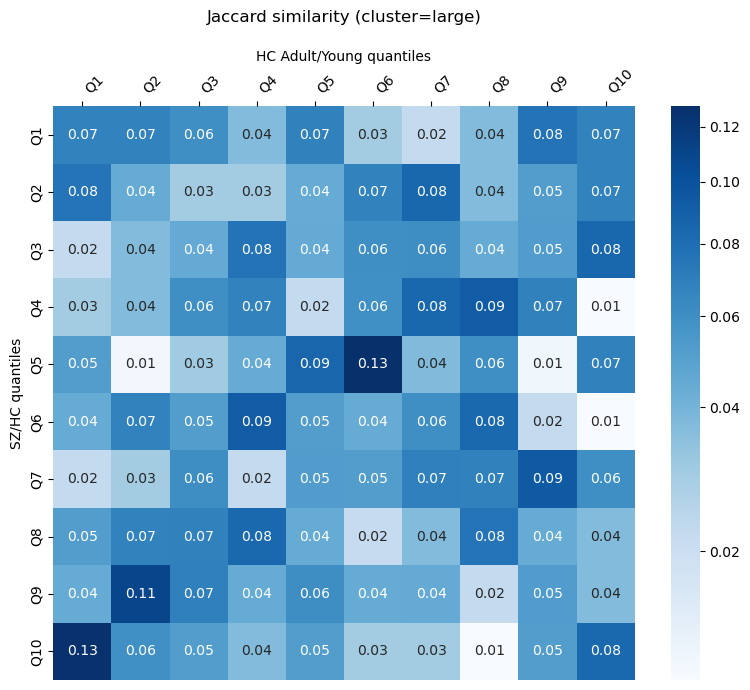

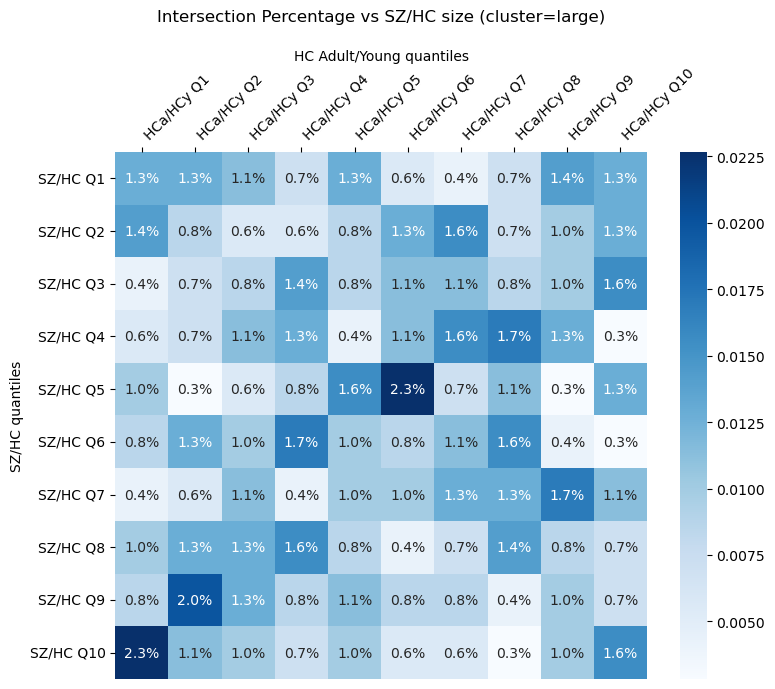

In [143]:
merged, similarity_matrix, intersection_percentage_matrix = border_size_group_analysis(df,sizes_tads,  border_size_group_value='large')

[border_size_group=medium] Number of top_sz_hc: 72
[border_size_group=medium] Number of top_hc_age: 72
[border_size_group=medium] Number of overlapping clusters in top quantile: 8
[border_size_group=medium] Fisher's exact test p-value for enrichment: 0.44, odds ratio: 1.13


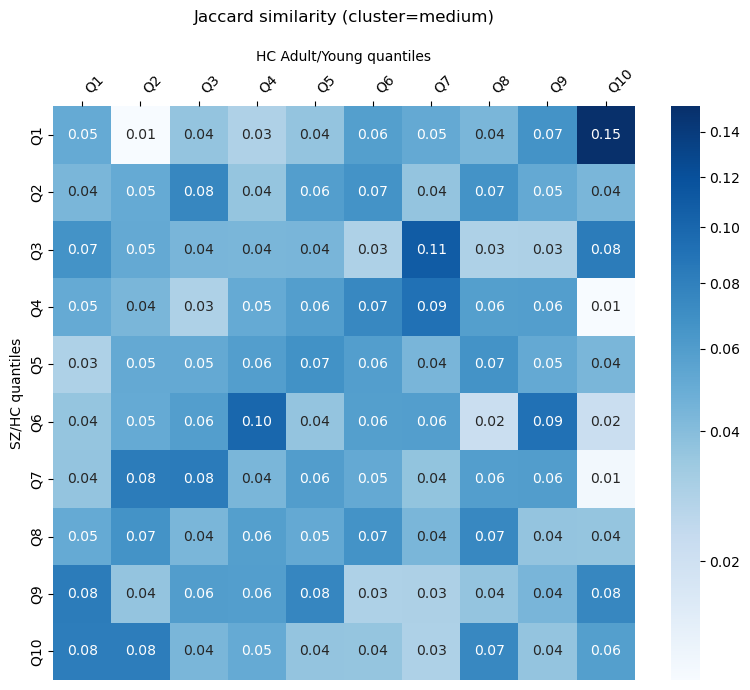

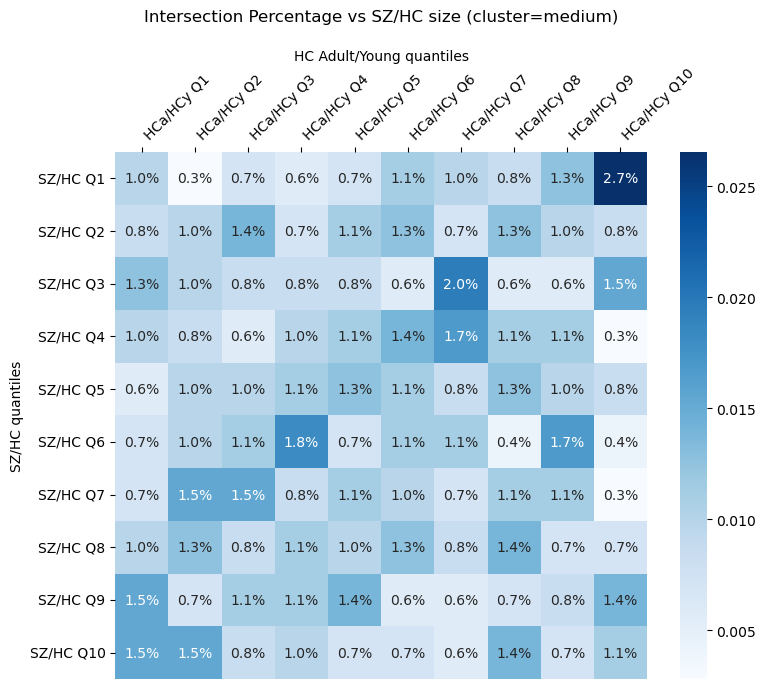

In [144]:
merged, similarity_matrix, intersection_percentage_matrix = border_size_group_analysis(df,sizes_tads,  border_size_group_value='medium')

[border_size_group=small] Number of top_sz_hc: 64
[border_size_group=small] Number of top_hc_age: 64
[border_size_group=small] Number of overlapping clusters in top quantile: 9
[border_size_group=small] Fisher's exact test p-value for enrichment: 0.178, odds ratio: 1.54


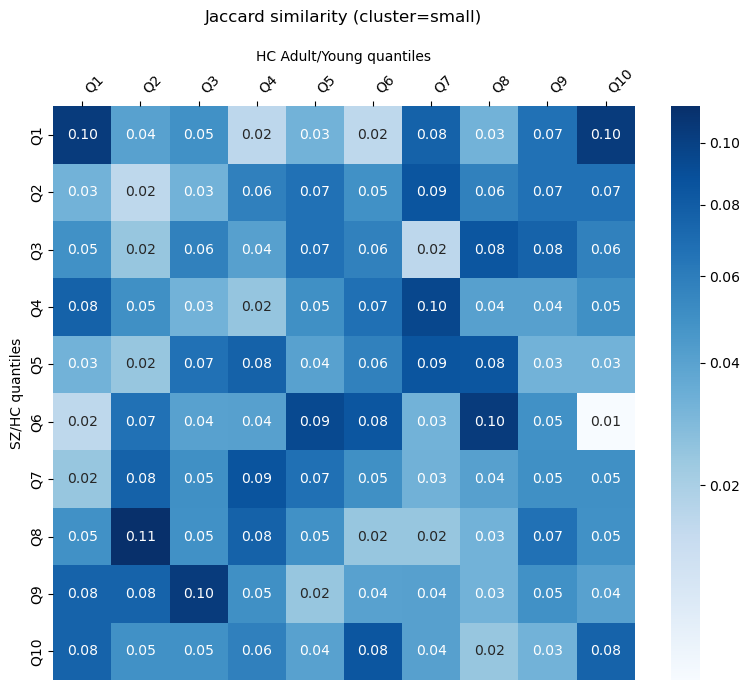

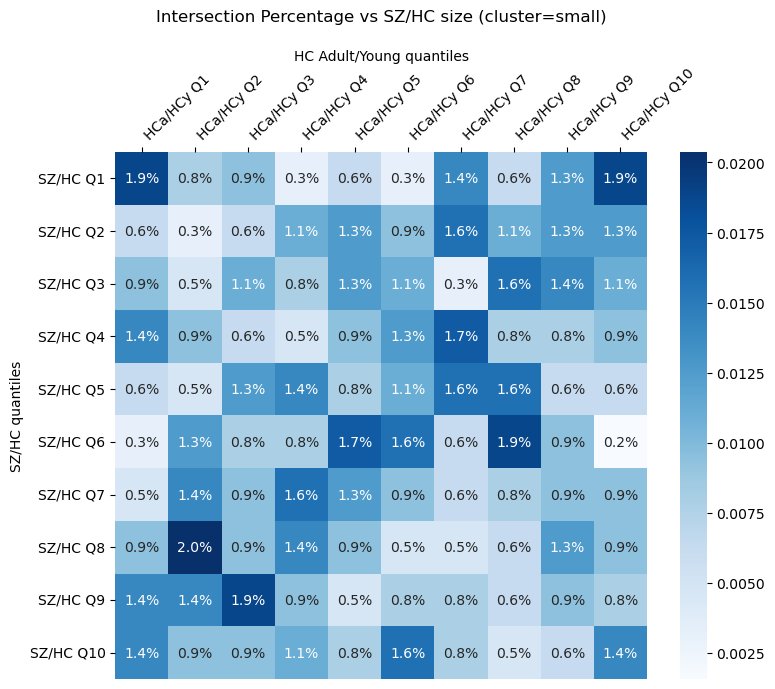

In [145]:
merged, similarity_matrix, intersection_percentage_matrix = border_size_group_analysis(df,sizes_tads,  border_size_group_value='small')